## setup

In [1]:
from moabb.datasets import BNCI2014_001
import moabb.paradigms as mp
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.evaluations import WithinSessionEvaluation
import random
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from functools import partial
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


c:\Users\Hzaab\Desktop\intern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = BNCI2014_001()


In [3]:
def scale_EEG(X, channels_to_scale, channels, scale_factor=2):
    X = X.copy()
        
    idx = [
        channels.index(ch)
        for ch in channels_to_scale
    ]

    X[:, idx, :] *= scale_factor
    
    return X

## Initial Test

In [10]:
num=10

all_scaled = []
used_combinations = set()

base_channels = [
    'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3',
    'CP4', 'CPz', 'Cz', 'FC2', 'FC3', 'FC4', 'FCz',
    'P1', 'P2', 'POz', 'Pz', 'C1', 'FC1', 'Fz'
]

while len(all_scaled) < num:
    num_inc=random.randint(1, 4)
    scaled = sorted(random.sample(base_channels, num_inc))
    key = tuple(scaled)

    if key in used_combinations:
        continue

    used_combinations.add(key)
    all_scaled.append(scaled)

print(all_scaled)

[['C2', 'C4'], ['CP1', 'FC1'], ['CP2', 'CP4', 'FC2'], ['FC3', 'FCz', 'P2'], ['C4', 'FC3', 'P1', 'POz'], ['C1', 'C3', 'CPz', 'POz'], ['C1'], ['C2', 'C3', 'CP2', 'FC4'], ['C2'], ['FC1']]


Train
Avg accuracy=  0.38250455
Avg balanced accuracy=  0.3821455
Avg macro F1=  0.28151792

Test
Avg accuracy=  0.42901793
Avg balanced accuracy=  0.42900795
Avg macro F1=  0.33337775


   subject session  score_accuracy
0        1  0train        0.448627
1        1   1test        0.491767
2        2  0train        0.299377
3        2   1test        0.278742
4        3  0train        0.544017
5        3   1test        0.535777
6        4  0train        0.331730
7        4   1test        0.404204
8        5  0train        0.270508
9        5   1test        0.288530
10       6  0train        0.316364
11       6   1test        0.311760
12       7  0train        0.461500
13       7   1test        0.519800
14       8  0train        0.386497
15       8   1test        0.514422
16       9  0train        0.383920
17       9   1test        0.516158


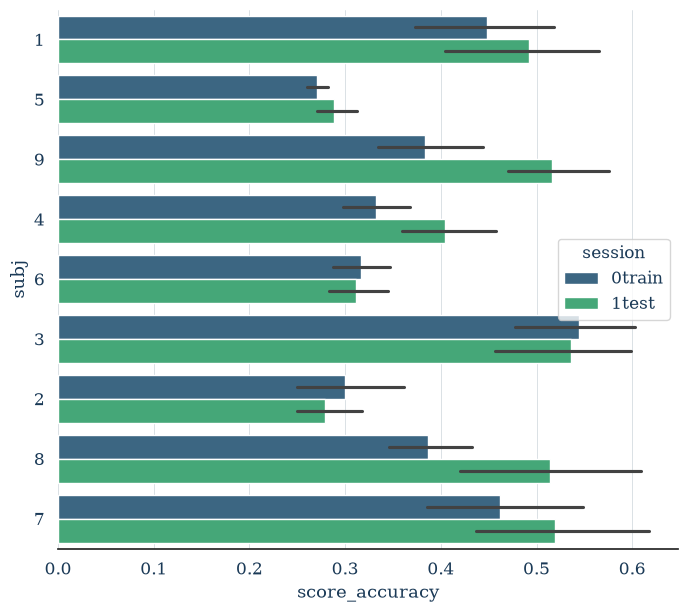

In [9]:
TrainAccuracy=0
TestAccuracy=0
BTrainAccuracy=0
BTestAccuracy=0
FTrain=0
FTest=0

for dset in all_avgs:
    TrainAccuracy+=dset.iloc[0]['Accuracy']
    TestAccuracy+=dset.iloc[1]['Accuracy']
    BTrainAccuracy+=dset.iloc[0]['Balanced Accuracy']
    BTestAccuracy+=dset.iloc[1]['Balanced Accuracy']
    FTrain+=dset.iloc[0]['score_f1_macro']
    FTest+=dset.iloc[1]['score_f1_macro']

print("Train")
print("Avg accuracy= ", TrainAccuracy/num)
print("Avg balanced accuracy= ", BTrainAccuracy/num)
print("Avg macro F1= ", FTrain/num)

print("\nTest")
print("Avg accuracy= ", TestAccuracy/num)
print("Avg balanced accuracy= ", BTestAccuracy/num)
print("Avg macro F1= ", FTest/num)
print("\n")

import pandas as pd

results = pd.concat(all_results, ignore_index=True)

avg_results = (
    results
    .groupby(["subject", "session"], as_index=False)["score_accuracy"]
    .mean()
)

print(avg_results)

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()



## Multiple Tests

In [3]:
factors=[0.5, 1, 1.5, 2, 2.5]


In [8]:
num=2

all_scaled = []
used_combinations = set()

base_channels = [
    'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3',
    'CP4', 'CPz', 'Cz', 'FC2', 'FC3', 'FC4', 'FCz',
    'P1', 'P2', 'POz', 'Pz', 'C1', 'FC1', 'Fz'
]

while len(all_scaled) < num:
    num_inc=random.randint(3,3)
    scaled = sorted(random.sample(base_channels, num_inc))
    key = tuple(scaled)

    if key in used_combinations:
        continue

    used_combinations.add(key)
    all_scaled.append(scaled)

print(all_scaled)

[['C3', 'C4', 'CP4'], ['FC4', 'P1', 'POz']]


In [7]:
accuracy=[]
for factor in factors:
    all_avgs = []

    for scaled in all_scaled:
            
        scaler = FunctionTransformer(
            partial(
                scale_EEG,
                channels_to_scale=scaled,
                channels=base_channels,
                scale_factor=factor
            )
        )

        pipeline = make_pipeline(
            scaler,
            CSP(n_components=8),
            LDA()
        )

        

        paradigm = mp.MotorImagery(
            scorer=["accuracy", "balanced_accuracy", "f1_macro"],
        )

        evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

        results = evaluation.process({"csp+lda": pipeline})
        
        avgRes=[]
        avgRes=pd.DataFrame(avgRes)
        avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

        all_avgs.append(avgRes)
    
    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    accuracy.append(TestAccuracy/num)

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 71 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 71 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 71 (2.2e-16 eps * 22 dim * 1.4e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 1.2e+02 (2.2e-16 eps * 22 dim * 2.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.2e+02 (2.2e-16 eps * 22 dim * 2.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.2e+02 (2.2e-16 eps *

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


...

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps * 22 dim * 2.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps * 22 dim * 2.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps *

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 22 dim * 2.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 22 dim * 2.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 22 di

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


In [12]:
accuracy

[np.float32(0.7081636), np.float32(0.70430195), np.float32(0.7053169)]

(0.7, 0.8)

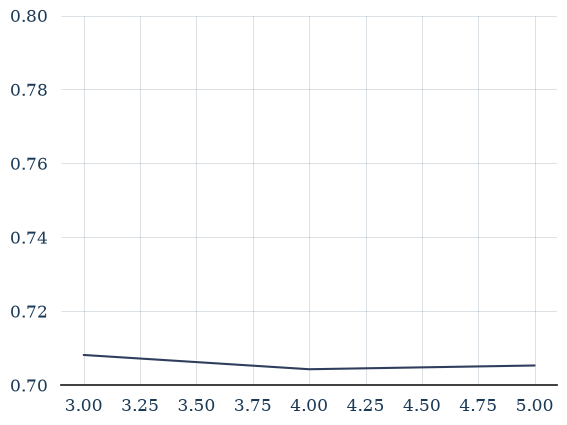

In [14]:
plt.plot(factors, accuracy)
plt.ylim(0.7, 0.8)

In [9]:
sum(accuracy)/len(accuracy)

np.float32(0.70592755)

In [18]:
X, labels, meta = paradigm.get_data(dataset=dataset, subjects=[1])

In [21]:
before=X[1, 1, :]

In [31]:
def scale_EEG2(X, scale_factor=5):
    X = X.copy()

    X*= scale_factor
    
    return X

In [32]:
after=scale_EEG2(before)

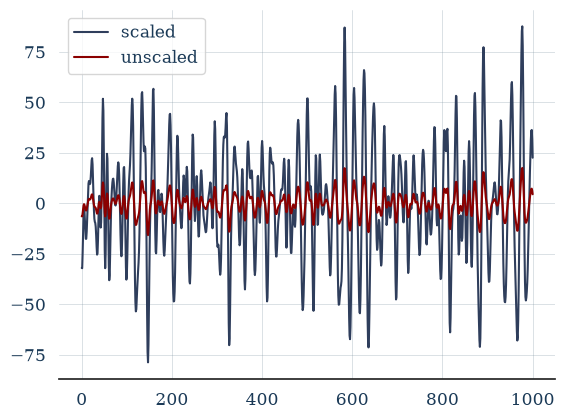

In [46]:
plt.plot(after, label="scaled")
plt.plot(before, color='#8B0000', label="unscaled")
plt.legend()
plt.show()

In [47]:
accuracy

[np.float32(0.7081636), np.float32(0.70430195), np.float32(0.7053169)]

Train
Avg accuracy=  0.65833837
Avg balanced accuracy=  0.0
Avg macro F1=  0.0

Test
Avg accuracy=  0.7053169
Avg balanced accuracy=  0.0
Avg macro F1=  0.0


   subject session  score_accuracy
0        1  0train        0.739504
1        1   1test        0.753297
2        2  0train        0.656080
3        2   1test        0.597036
4        3  0train        0.861222
5        3   1test        0.864489
6        4  0train        0.537750
7        4   1test        0.673805
8        5  0train        0.367937
9        5   1test        0.423654
10       6  0train        0.489716
11       6   1test        0.485783
12       7  0train        0.798790
13       7   1test        0.861162
14       8  0train        0.808953
15       8   1test        0.795039
16       9  0train        0.676830
17       9   1test        0.847187


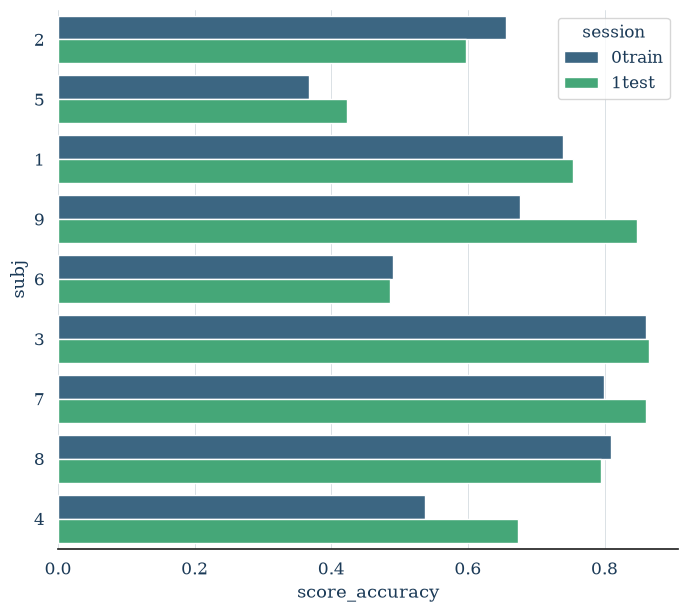

In [51]:
TrainAccuracy=0
TestAccuracy=0
BTrainAccuracy=0
BTestAccuracy=0
FTrain=0
FTest=0

for dset in all_avgs:
    TrainAccuracy+=dset.iloc[0]['Accuracy']
    TestAccuracy+=dset.iloc[1]['Accuracy']

print("Train")
print("Avg accuracy= ", TrainAccuracy/num)
print("Avg balanced accuracy= ", BTrainAccuracy/num)
print("Avg macro F1= ", FTrain/num)

print("\nTest")
print("Avg accuracy= ", TestAccuracy/num)
print("Avg balanced accuracy= ", BTestAccuracy/num)
print("Avg macro F1= ", FTest/num)
print("\n")

import pandas as pd


avg_results = (
    results
    .groupby(["subject", "session"], as_index=False)["score_accuracy"]
    .mean()
)

print(avg_results)

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()



## Train only affected

In [29]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


class TrainOnlyScalerClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, channels_to_scale, channels, scale_factor=2, n_components=8):
        self.channels_to_scale = channels_to_scale
        self.channels = channels
        self.scale_factor = scale_factor
        self.n_components = n_components

    def _scale_train(self, X):
        X = X.copy()
        idx = [self.channels.index(ch) for ch in self.channels_to_scale]
        X[:, idx, :] *= self.scale_factor
        return X

    def fit(self, X, y):
        X_train_scaled = self._scale_train(X)

        self.clf_ = make_pipeline(
            CSP(n_components=self.n_components),
            LDA()
        )

        self.clf_.fit(X_train_scaled, y)
        return self

    def predict(self, X):
        return self.clf_.predict(X)

    def predict_proba(self, X):
        return self.clf_.predict_proba(X)

In [30]:
accuracy=[]
for factor in factors:
    all_avgs = []

    for scaled in all_scaled:
            
        pipeline = TrainOnlyScalerClassifier(
            channels_to_scale=scaled,
            channels=base_channels,
            scale_factor=factor,
            n_components=8
        )

        paradigm = mp.MotorImagery(
            scorer=["accuracy", "balanced_accuracy", "f1_macro"],
            channels=base_channels
        )

        evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

        results = evaluation.process({"csp+lda-trainScaledOnly": pipeline})
        
        avgRes=[]
        avgRes=pd.DataFrame(avgRes)
        avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

        all_avgs.append(avgRes)
    
    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    accuracy.append(TestAccuracy/num)

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 75 (2.2e-16 eps * 22 dim * 1.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 75 (2.2e-16 eps * 22 dim * 1.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 75 (2.2e-16 eps * 22 dim * 1.5e+

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 45 (2.2e-16 eps * 22 dim * 9.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 45 (2.2e-16 eps * 22 dim * 9.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 45 (2.2e-16 eps * 22 dim * 9.3e+

Choosing from all possible events


...

Computing rank from data with rank=None
    Using tolerance 53 (2.2e-16 eps * 22 dim * 1.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 53 (2.2e-16 eps * 22 dim * 1.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 53 (2.2e-16 eps * 22 dim * 1.1e+

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 51 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 51 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 51 (2.2e-16 eps * 22 dim * 1e+16  ma

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 58 (2.2e-16 eps * 22 dim * 1.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 58 (2.2e-16 eps * 22 dim * 1.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 58 (2.2e-16 eps * 22 dim * 1.2e+

In [45]:
factors

[0.5, 1, 1.5, 2, 2.5]

In [ ]:
factors2=factors.copy()
acc2=accuracy.copy()

In [51]:
factors2.pop(1)

1

In [52]:
acc2.pop(1)

np.float32(0.7034886)

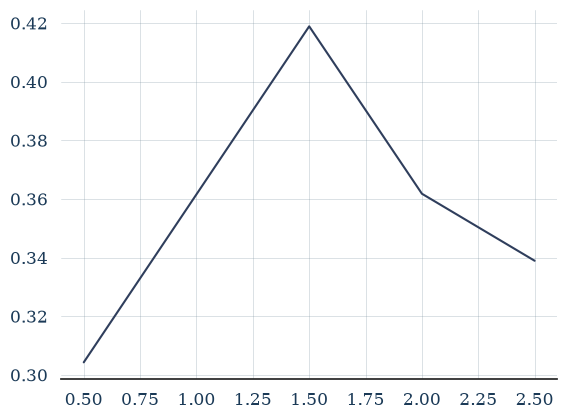

In [54]:
plt.plot(factors2, acc2)

## Test only affected

In [14]:
class TestOnlyScalerClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, channels_to_scale, channels, scale_factor=2, n_components=8):
        self.channels_to_scale = channels_to_scale
        self.channels = channels
        self.scale_factor = scale_factor
        self.n_components = n_components

    def _scale_test(self, X):
        X = X.copy()
        idx = [self.channels.index(ch) for ch in self.channels_to_scale]
        X[:, idx, :] *= self.scale_factor
        return X

    def fit(self, X, y):
        self.clf_ = make_pipeline(
            CSP(n_components=self.n_components),
            LDA()
        )

        self.clf_.fit(X, y)
        return self

    def predict(self, X):
        X_test_scaled = self._scale_test(X)
        return self.clf_.predict(X_test_scaled)

    def predict_proba(self, X):
        X_test_scaled = self._scale_test(X)
        return self.clf_.predict_proba(X_test_scaled)

In [15]:
accuracy=[]
for factor in factors:
    all_avgs = []

    for scaled in all_scaled:
            
        pipeline = TestOnlyScalerClassifier(
            channels_to_scale=scaled,
            channels=base_channels,
            scale_factor=factor,
            n_components=8
        )

        paradigm = mp.MotorImagery(
            scorer=["accuracy", "balanced_accuracy", "f1_macro"],
            channels=base_channels
        )

        evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

        results = evaluation.process({"csp+lda-trainScaledOnly": pipeline})
        
        avgRes=[]
        avgRes=pd.DataFrame(avgRes)
        avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

        all_avgs.append(avgRes)
    
    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    accuracy.append(TestAccuracy/num)

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 80 (2.2e-16 eps * 22 dim * 1.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 80 (2.2e-16 eps * 22 dim * 1.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 81 (2.2e-16 eps * 22 dim * 1.7e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9e+15

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


...

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 69 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 70 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 70 (2.2e-16 eps * 22 dim * 1.4e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 81 (2.2e-16 eps * 22 dim * 1.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 80 (2.2e-16 eps * 22 dim * 1.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 81 (2.2e-16 eps * 22 dim * 1.7e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


In [19]:
factors2=factors.copy()
acc2=accuracy.copy()

factors2.pop(1)
acc2.pop(1)

np.float32(0.7056329)

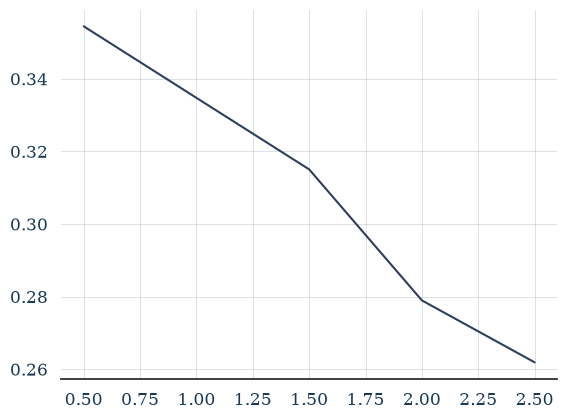

In [20]:
plt.plot(factors2, acc2)

## Train, multiple scaling factors

In [17]:
import random
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


class FullyRandomScalerClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, channels, n_components=8):
        self.channels = channels
        self.n_components = n_components

    def _augment_train(self, X, y):
        # Keep originals
        X_aug = [X]
        y_aug = [y]

        # Create one randomly scaled copy
        X_scaled = X.copy()

        for idx in range(len(self.channels)):
            scale_factor = random.uniform(0.5, 2.5)
            X_scaled[:, idx, :] *= scale_factor

        X_aug.append(X_scaled)
        y_aug.append(y.copy())

        X_aug = np.concatenate(X_aug, axis=0)
        y_aug = np.concatenate(y_aug, axis=0)

        return X_aug, y_aug

    def fit(self, X, y):
        X_train_aug, y_train_aug = self._augment_train(X, y)

        self.clf_ = make_pipeline(
            CSP(n_components=self.n_components),
            LDA()
        )

        self.clf_.fit(X_train_aug, y_train_aug)
        return self

    def predict(self, X):
        return self.clf_.predict(X)

    def predict_proba(self, X):
        return self.clf_.predict_proba(X)

In [18]:
pipeline = FullyRandomScalerClassifier(
        channels=base_channels,
        n_components=8
    )

paradigm = mp.MotorImagery(
        scorer=["accuracy", "balanced_accuracy", "f1_macro"],
        channels=base_channels
    )

evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

results = evaluation.process({"csp+lda-trainScaledOnly": pipeline})


Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 1.1e+02 (2.2e-16 eps * 22 dim * 2.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.1e+02 (2.2e-16 eps * 22 dim * 2.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1e+02 (2.2e-16 eps * 2

In [19]:
results.groupby('session')['score_accuracy'].mean()

session
0train    0.627653
1test     0.664852
Name: score_accuracy, dtype: float32

## Both, multiple scaling factors

In [28]:
import random
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


class FullyRandomScalerClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, channels, n_components=8):
        self.channels = channels
        self.n_components = n_components

    def _scale_test(self, X):
        for idx in range(len(self.channels)): 
            scale_factor=random.uniform(0.5, 2.5) 
            X[:, idx, :] *= scale_factor 
        X = X.copy() 
        return X
    
    def _augment_train(self, X, y):
        X_aug = [X]
        y_aug = [y]

        X_scaled = X.copy()

        for idx in range(len(self.channels)):
            scale_factor = random.uniform(0.5, 2.5)
            X_scaled[:, idx, :] *= scale_factor

        X_aug.append(X_scaled)
        y_aug.append(y.copy())

        X_aug = np.concatenate(X_aug, axis=0)
        y_aug = np.concatenate(y_aug, axis=0)

        return X_aug, y_aug

    def fit(self, X, y):
        X_train_aug, y_train_aug = self._augment_train(X, y)

        self.clf_ = make_pipeline(
            CSP(n_components=self.n_components),
            LDA()
        )

        self.clf_.fit(X_train_aug, y_train_aug)
        return self

    def predict(self, X):
        X_test_scaled = self._scale_test(X)
        return self.clf_.predict(X_test_scaled)

    def predict_proba(self, X):
        X_test_scaled = self._scale_test(X)
        return self.clf_.predict_proba(X_test_scaled)

In [29]:
pipeline = FullyRandomScalerClassifier(
        channels=base_channels,
        n_components=8
    )

paradigm = mp.MotorImagery(
        scorer=["accuracy", "balanced_accuracy", "f1_macro"],
        channels=base_channels
    )

evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

results = evaluation.process({"csp+lda-trainScaledOnly": pipeline})


Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 1.3e+02 (2.2e-16 eps * 22 dim * 2.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.3e+02 (2.2e-16 eps * 22 dim * 2.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.3e+02 (2.2e-16 eps *

In [30]:
results.groupby('session')['score_accuracy'].mean()

session
0train    0.258849
1test     0.257693
Name: score_accuracy, dtype: float32

## increased samples

In [31]:
import random
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


class FullyRandomScalerClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, channels, n_components=8, n_augmentations=5):
        self.channels = channels
        self.n_components = n_components
        self.n_augmentations = n_augmentations

    def _augment_train(self, X, y):
        X_list = [X]
        y_list = [y]

        for _ in range(self.n_augmentations):
            X_scaled = X.copy()

            for idx in range(len(self.channels)):
                scale_factor = random.uniform(0.5, 2.5)
                X_scaled[:, idx, :] *= scale_factor

            X_list.append(X_scaled)
            y_list.append(y)

        return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

    def _scale_test(self, X):
        for idx in range(len(self.channels)): 
            scale_factor=random.uniform(0.5, 2.5) 
            X[:, idx, :] *= scale_factor 
        X = X.copy() 
        return X
    

    def fit(self, X, y):
        X_train_aug, y_train_aug = self._augment_train(X, y)

        self.clf_ = make_pipeline(
            CSP(n_components=self.n_components),
            LDA()
        )

        self.clf_.fit(X_train_aug, y_train_aug)
        return self

    def predict(self, X):
        X_test_scaled = self._scale_test(X)
        return self.clf_.predict(X_test_scaled)

    def predict_proba(self, X):
        X_test_scaled = self._scale_test(X)
        return self.clf_.predict_proba(X_test_scaled)

In [36]:
pipeline = FullyRandomScalerClassifier(
        channels=base_channels,
        n_components=8,
        n_augmentations=20
    )

paradigm = mp.MotorImagery(
        scorer=["accuracy", "balanced_accuracy", "f1_macro"],
        channels=base_channels
    )

evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

results = evaluation.process({"csp+lda-trainScaledOnly": pipeline})


Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 3.2e+02 (2.2e-16 eps * 22 dim * 6.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.2e+02 (2.2e-16 eps * 22 dim * 6.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.2e+02 (2.2e-16 eps *

In [37]:
results.groupby('session')['score_accuracy'].mean()

session
0train    0.330477
1test     0.350259
Name: score_accuracy, dtype: float32